# **Notebook 5: Bio_ClinicalBERT Residual Gated Fusion Hyperparameter and Augmentation Tuning**

**Description:** This notebook tunes the selected Bio_ClinicalBERT residual gated fusion model using the original full-image pipeline selected in Notebook 04. It keeps the dataset split, label space, text encoder, image encoder, and fusion architecture fixed, then runs targeted augmentation, learning-rate, dropout, weight-decay, and class-weight trials before final Grad-CAM interpretation.

**Main Questions This Notebook Should Answer:**
- Does conservative tuning improve validation macro F1?
- Do those validation gains hold on the held-out test set?
- Should the tuned checkpoint replace the Notebook 04 full-image checkpoint before Notebook 06 generates case-level Grad-CAM evidence?

---

# **Part 1: Configuration**
### **Imports**


In [1]:
from pathlib import Path
import sys
import gc
import json
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

from transformers import AutoModel, AutoTokenizer

# Ensure Python can find the local xray_fusion package.
PROJECT_ROOT = next(
    (candidate for candidate in (Path.cwd(), *Path.cwd().parents) if (candidate / "src" / "xray_fusion").exists()),
    Path.cwd(),
)
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from xray_fusion.config import DEFAULT_IMAGE_SIZE, DEFAULT_MAX_LEN, find_project_root
from xray_fusion import data as xray_data
from xray_fusion import models as xray_models
from xray_fusion import training as xray_training
from xray_fusion import evaluation as xray_eval
from xray_fusion import segmentation as xray_segmentation
from xray_fusion import gradcam as xray_gradcam


### **Paths and Dataset Splits**


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

project_root = Path.cwd().resolve()
if not (project_root / "splits").exists():
    project_root = project_root.parent

base_dir = project_root
split_dir = base_dir / "splits"
train_csv = split_dir / "train.csv"
val_csv = split_dir / "val.csv"
test_csv = split_dir / "test.csv"

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)


Using device: cuda


### **Fixed Training Configuration**


In [3]:
HF_CACHE_DIR = base_dir / "hf_cache"
RESOLVED_TEXT_ENCODER_DIR = (
    base_dir
    / "Experiments"
    / "outputs"
    / "experiment_03_gated_fusion_ablation"
    / "resolved_hf_models"
    / "emilyalsentzer__Bio_ClinicalBERT"
)
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
MAX_LEN = 64
DEFAULT_EPOCHS = 10
FREEZE_BERT = True
FREEZE_IMAGE_BACKBONE = False
TEXT_ENCODER_NAME = "emilyalsentzer/Bio_ClinicalBERT"
TOKENIZER_NAME = TEXT_ENCODER_NAME
TEXT_ENCODER_SOURCE = str(RESOLVED_TEXT_ENCODER_DIR) if RESOLVED_TEXT_ENCODER_DIR.exists() else TEXT_ENCODER_NAME
TOKENIZER_SOURCE = TEXT_ENCODER_SOURCE
TEXT_ENCODER_SPEC = {
    "name": "Bio_ClinicalBERT",
    "slug": "bio_clinicalbert",
    "loader": "auto",
    "model_name": TEXT_ENCODER_SOURCE,
    "tokenizer_name": TOKENIZER_SOURCE,
}
MODEL_ARCHITECTURE = "Bio_ClinicalBERT residual gated fusion"
FUSION_BLOCK_NAME = "ResidualGatedFusionBlock"
IMAGE_PIPELINE_NAME = "a_original_full"
IMAGE_PIPELINE_SOURCE = "notebook_04_original_full"
SELECTION_METRIC = "best_val_macro_f1"
EXPERIMENT_NAME = "experiment_05_gated_hypertuning_augmentation"
OUTPUT_DIR = base_dir / "Experiments" / "outputs" / EXPERIMENT_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_CHECKPOINTS = True
RUN_TEST_FOR_EACH_TRIAL = False
CHECKPOINT_POLICY = (
    "last checkpoint saved every epoch; best checkpoint saved on validation macro F1 improvement"
)

print("Saving artifacts to:", OUTPUT_DIR)
print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("Text encoder:", TEXT_ENCODER_NAME)
print("Text encoder source:", TEXT_ENCODER_SOURCE)
print("Fusion architecture:", MODEL_ARCHITECTURE)
print("Fusion block:", FUSION_BLOCK_NAME)
print("Image pipeline:", IMAGE_PIPELINE_NAME)
print("Checkpoint policy:", CHECKPOINT_POLICY)


Saving artifacts to: PROJECT_ROOT\Experiments\outputs\experiment_05_gated_hypertuning_augmentation
Train shape: (2200, 15)
Val shape: (472, 15)
Test shape: (472, 15)
Text encoder: emilyalsentzer/Bio_ClinicalBERT
Text encoder source: PROJECT_ROOT\Experiments\outputs\experiment_03_gated_fusion_ablation\resolved_hf_models\emilyalsentzer__Bio_ClinicalBERT
Fusion architecture: Bio_ClinicalBERT residual gated fusion
Fusion block: ResidualGatedFusionBlock
Image pipeline: a_original_full
Checkpoint policy: last checkpoint saved every epoch; best checkpoint saved on validation macro F1 improvement


---

# **Part 2: Labels, Text Resources, and Augmentation Recipes**

### **Encode Labels and Class Counts**


In [4]:
label_encoder = LabelEncoder()
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["label_enc"] = label_encoder.fit_transform(train_df["clean_label"])
val_df["label_enc"] = label_encoder.transform(val_df["clean_label"])
test_df["label_enc"] = label_encoder.transform(test_df["clean_label"])

label_names = list(label_encoder.classes_)
num_classes = len(label_names)

class_counts = train_df["label_enc"].value_counts().sort_index().to_numpy()
print("Classes:", label_names)
print("Train class counts:", dict(zip(label_names, class_counts)))


Classes: ['cardiomegaly', 'chronic_lung_disease', 'normal', 'pleural_effusion', 'pneumonia_or_opacity']
Train class counts: {'cardiomegaly': np.int64(178), 'chronic_lung_disease': np.int64(75), 'normal': np.int64(1611), 'pleural_effusion': np.int64(120), 'pneumonia_or_opacity': np.int64(216)}


### **Load Bio_ClinicalBERT text resources**


In [5]:
tokenizer = AutoTokenizer.from_pretrained(
    TOKENIZER_SOURCE,
    cache_dir=HF_CACHE_DIR,
    local_files_only=Path(TOKENIZER_SOURCE).exists(),
)
print("Tokenizer loaded from:", TOKENIZER_SOURCE)



Tokenizer loaded from: PROJECT_ROOT\Experiments\outputs\experiment_03_gated_fusion_ablation\resolved_hf_models\emilyalsentzer__Bio_ClinicalBERT


### **Define Evaluation Transform**


In [6]:
base_eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


### **Define Training Augmentation Recipes**


In [7]:
AUGMENTATION_RECIPES = AUGMENTATION_RECIPES = {
    "none": transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
    ]),
    "light_geometric": transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=7),
        transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.95, 1.05)),
        transforms.ToTensor(),
    ]),
    "intensity_jitter": transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ColorJitter(brightness=0.12, contrast=0.12),
        transforms.ToTensor(),
    ]),
    "combined_light": transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=7),
        transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.95, 1.05)),
        transforms.ColorJitter(brightness=0.10, contrast=0.10),
        transforms.ToTensor(),
    ]),
    "combined_erasing": transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=7),
        transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.95, 1.05)),
        transforms.ColorJitter(brightness=0.10, contrast=0.10),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.20, scale=(0.01, 0.04), ratio=(0.4, 2.5), value=0.0),
    ]),
}

pd.DataFrame(
    [{"augmentation": name, "transform": str(transform)} for name, transform in AUGMENTATION_RECIPES.items()]
).to_csv(OUTPUT_DIR / "augmentation_recipes.csv", index=False)


---

# **Part 3: Dataset and Model Definition**

### **Multimodal Dataset Class**


In [8]:
class XRayMultimodalDataset(xray_data.XRayMultimodalDataset):
    def __init__(self, df, tokenizer, image_transform=None, max_len=MAX_LEN):
        super().__init__(
            df,
            tokenizer=tokenizer,
            image_transform=image_transform,
            max_len=max_len,
            label_key="labels",
        )


### **Dual-View Image Encoder**


In [9]:
DualImageEncoder = xray_models.DualImageEncoder
ResidualGatedFusionBlock = xray_models.ResidualGatedFusionBlock


### **Bio_ClinicalBERT Residual Gated Fusion Classifier**

In [10]:
class BioClinicalBertGatedFusionClassifier(xray_models.SelectedEncoderGatedFusionModel):
    def __init__(
        self,
        num_classes,
        text_dropout=0.2,
        classifier_dropout=0.3,
        freeze_bert=FREEZE_BERT,
        freeze_image_backbone=FREEZE_IMAGE_BACKBONE,
        cache_dir=None,
    ):
        super().__init__(
            encoder_spec=TEXT_ENCODER_SPEC,
            num_classes=num_classes,
            fusion_block=None,
            fusion_dim=256,
            fusion_dropout=text_dropout,
            freeze_bert=freeze_bert,
            freeze_image_backbone=freeze_image_backbone,
            cache_dir=cache_dir,
        )
        self.classifier = nn.Sequential(
            nn.Linear(self.fusion_block.output_dim, 256),
            nn.ReLU(),
            nn.Dropout(classifier_dropout),
            nn.Linear(256, num_classes),
        )


---

# **Part 4: Training and Evaluation Utilities**

### **Dataloader and Class Weight Helpers**


In [11]:
def make_loaders(augmentation_name, batch_size=BATCH_SIZE):
    train_transform = AUGMENTATION_RECIPES[augmentation_name]
    train_loader = DataLoader(
        XRayMultimodalDataset(train_df, tokenizer, image_transform=train_transform),
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )
    val_loader = DataLoader(
        XRayMultimodalDataset(val_df, tokenizer, image_transform=base_eval_transform),
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )
    test_loader = DataLoader(
        XRayMultimodalDataset(test_df, tokenizer, image_transform=base_eval_transform),
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )
    return train_loader, val_loader, test_loader


def class_weight_tensor(power=1.0):
    counts = torch.tensor(class_counts, dtype=torch.float32)
    weights = counts.sum() / (len(counts) * counts)
    weights = weights.pow(power)
    weights = weights / weights.mean()
    return weights.to(device)


### **Optimizer and Scheduler Helpers**


In [12]:
configure_optimizer = xray_training.configure_optimizer
build_scheduler = xray_training.build_scheduler


### **Training Loop**


In [13]:
def train_one_epoch(model, loader, criterion, optimizer):
    loss, accuracy = xray_training.train_one_epoch(
        model, loader, criterion, optimizer, device, task_type="fusion", desc="Train Fusion"
    )
    return {
        "loss": float(loss),
        "accuracy": float(accuracy),
    }


### **Evaluation Loop**


In [14]:
def evaluate(model, loader, criterion, desc="Eval"):
    loss, acc, y_true, y_pred, y_prob = xray_training.evaluate_model(
        model, loader, criterion, device, task_type="fusion", desc=desc
    )
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    report = classification_report(y_true, y_pred, target_names=label_names, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    return {
        "loss": loss,
        "accuracy": acc,
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "report": report,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }


### **Artifact Helpers**


In [15]:
save_json = xray_eval.save_json
torch_load = xray_models.torch_load

def save_confusion_matrix_figure(cm, title, save_path):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(label_names)))
    ax.set_yticks(range(len(label_names)))
    ax.set_xticklabels(label_names, rotation=45, ha="right")
    ax.set_yticklabels(label_names)
    for i in range(len(label_names)):
        for j in range(len(label_names)):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


---

# **Part 5: Trial Plan**

The trial groups separate augmentation, dropout, learning-rate, and class-balance questions so each result can be interpreted against a clear baseline.
### **Shared Hyperparameter Settings**


In [16]:
DEFAULT_TRIAL_SETTINGS = {
    "epochs": DEFAULT_EPOCHS,
    "batch_size": BATCH_SIZE,
    "lr_text": 2e-5,
    "lr_image": 1e-4,
    "weight_decay": 1e-4,
    "text_dropout": 0.2,
    "classifier_dropout": 0.3,
    "class_weight_power": 1.0,
    "scheduler": "constant",
    "freeze_bert": FREEZE_BERT,
    "freeze_image_backbone": FREEZE_IMAGE_BACKBONE,
}

TUNING_COLUMNS = [
    "trial_name",
    "trial_group",
    "augmentation",
    "epochs",
    "batch_size",
    "lr_text",
    "lr_image",
    "weight_decay",
    "text_dropout",
    "classifier_dropout",
    "class_weight_power",
    "scheduler",
    "freeze_bert",
    "freeze_image_backbone",
]


def make_trial(trial_name, trial_group, augmentation, **overrides):
    config = {
        **DEFAULT_TRIAL_SETTINGS,
        "trial_name": trial_name,
        "trial_group": trial_group,
        "augmentation": augmentation,
    }
    config.update(overrides)
    return config


### **Baseline and Simple Augmentation Block**


In [17]:
BASELINE_TRIAL = make_trial(
    trial_name="baseline_no_aug",
    trial_group="01_baseline_simple_aug",
    augmentation="none",
)

SIMPLE_AUGMENTATION_TRIALS = [
    make_trial(
        trial_name="light_geometric_default_lr",
        trial_group="01_baseline_simple_aug",
        augmentation="light_geometric",
    ),
    make_trial(
        trial_name="intensity_jitter_default_lr",
        trial_group="01_baseline_simple_aug",
        augmentation="intensity_jitter",
    ),
]


### **Combined Augmentation Block**


In [18]:
COMBINED_AUGMENTATION_TRIALS = [
    make_trial(
        trial_name="combined_light_default_lr",
        trial_group="02_combined_aug",
        augmentation="combined_light",
    ),
    make_trial(
        trial_name="combined_erasing_default_lr",
        trial_group="02_combined_aug",
        augmentation="combined_erasing",
    ),
]


### **Dropout Tuning Block**


In [19]:
DROPOUT_TUNING_TRIALS = [
    make_trial(
        trial_name="intensity_jitter_low_dropout",
        trial_group="03_dropout_tuning",
        augmentation="intensity_jitter",
        text_dropout=0.1,
        classifier_dropout=0.2,
    ),
    make_trial(
        trial_name="intensity_jitter_medium_high_dropout",
        trial_group="03_dropout_tuning",
        augmentation="intensity_jitter",
        text_dropout=0.3,
        classifier_dropout=0.4,
    ),
    make_trial(
        trial_name="intensity_jitter_classifier_dropout_only",
        trial_group="03_dropout_tuning",
        augmentation="intensity_jitter",
        text_dropout=0.2,
        classifier_dropout=0.5,
    ),
]


### **Learning Rate Tuning Block**


In [20]:
LEARNING_RATE_TUNING_TRIALS = [
    make_trial(
        trial_name="intensity_jitter_lower_image_lr",
        trial_group="04_learning_rate_tuning",
        augmentation="intensity_jitter",
        lr_text=2e-5,
        lr_image=5e-5,
    ),
    make_trial(
        trial_name="intensity_jitter_higher_image_lr",
        trial_group="04_learning_rate_tuning",
        augmentation="intensity_jitter",
        lr_text=2e-5,
        lr_image=2e-4,
    ),
    make_trial(
        trial_name="intensity_jitter_lower_text_lr",
        trial_group="04_learning_rate_tuning",
        augmentation="intensity_jitter",
        lr_text=1e-5,
        lr_image=1e-4,
    ),
]


### **Regularization and Class-Balance Block**


In [21]:
REGULARIZATION_CLASS_BALANCE_TRIALS = [
    make_trial(
        trial_name="intensity_jitter_stronger_weight_decay",
        trial_group="05_regularization_class_balance",
        augmentation="intensity_jitter",
        weight_decay=5e-4,
    ),
    make_trial(
        trial_name="intensity_jitter_soft_class_weights",
        trial_group="05_regularization_class_balance",
        augmentation="intensity_jitter",
        class_weight_power=0.5,
    ),
    make_trial(
        trial_name="intensity_jitter_regularized_mix",
        trial_group="05_regularization_class_balance",
        augmentation="intensity_jitter",
        weight_decay=5e-4,
        text_dropout=0.3,
        classifier_dropout=0.4,
        class_weight_power=0.5,
    ),
]


### **Trial Registry**


In [22]:
TRIAL_GROUPS = {
    "01_baseline_simple_aug": [BASELINE_TRIAL] + SIMPLE_AUGMENTATION_TRIALS,
    "02_combined_aug": COMBINED_AUGMENTATION_TRIALS,
    "03_dropout_tuning": DROPOUT_TUNING_TRIALS,
    "04_learning_rate_tuning": LEARNING_RATE_TUNING_TRIALS,
    "05_regularization_class_balance": REGULARIZATION_CLASS_BALANCE_TRIALS,
}

TRIALS = [trial for group_trials in TRIAL_GROUPS.values() for trial in group_trials]
TRIAL_BY_NAME = {trial["trial_name"]: trial for trial in TRIALS}

planned_trials_df = pd.DataFrame(TRIALS)[TUNING_COLUMNS]
planned_trials_df.to_csv(OUTPUT_DIR / "planned_trials.csv", index=False)

print("Available trial groups:")
for group_name, group_trials in TRIAL_GROUPS.items():
    print(f"- {group_name}: {len(group_trials)} trials")

display(planned_trials_df)


Available trial groups:
- 01_baseline_simple_aug: 3 trials
- 02_combined_aug: 2 trials
- 03_dropout_tuning: 3 trials
- 04_learning_rate_tuning: 3 trials
- 05_regularization_class_balance: 3 trials


,trial_name,trial_group,augmentation,epochs,batch_size,lr_text,lr_image,weight_decay,text_dropout,classifier_dropout,class_weight_power,scheduler,freeze_bert,freeze_image_backbone
0,baseline_no_aug,01_baseline_simple_aug,none,10,32,0.00002,0.00010,0.0001,0.2,0.3,1.0,constant,True,False
1,light_geometric_default_lr,01_baseline_simple_aug,light_geometric,10,32,0.00002,0.00010,0.0001,0.2,0.3,1.0,constant,True,False
2,intensity_jitter_default_lr,01_baseline_simple_aug,intensity_jitter,10,32,0.00002,0.00010,0.0001,0.2,0.3,1.0,constant,True,False
3,combined_light_default_lr,02_combined_aug,combined_light,10,32,0.00002,0.00010,0.0001,0.2,0.3,1.0,constant,True,False
4,combined_erasing_default_lr,02_combined_aug,combined_erasing,10,32,0.00002,0.00010,0.0001,0.2,0.3,1.0,constant,True,False
5,intensity_jitter_low_dropout,03_dropout_tuning,intensity_jitter,10,32,0.00002,0.00010,0.0001,0.1,0.2,1.0,constant,True,False
6,intensity_jitter_medium_high_dropout,03_dropout_tuning,intensity_jitter,10,32,0.00002,0.00010,0.0001,0.3,0.4,1.0,constant,True,False
7,intensity_jitter_classifier_dropout_only,03_dropout_tuning,intensity_jitter,10,32,0.00002,0.00010,0.0001,0.2,0.5,1.0,constant,True,False
8,intensity_jitter_lower_image_lr,04_learning_rate_tuning,intensity_jitter,10,32,0.00002,0.00005,0.0001,0.2,0.3,1.0,constant,True,False
9,intensity_jitter_higher_image_lr,04_learning_rate_tuning,intensity_jitter,10,32,0.00002,0.00020,0.0001,0.2,0.3,1.0,constant,True,False


---

# **Part 6: Run Hyperparameter and Augmentation Trials**

### **Define Single-Trial Runner**


In [23]:
def run_trial(config):
    trial_slug = config["trial_name"]
    trial_dir = OUTPUT_DIR / trial_slug
    trial_dir.mkdir(parents=True, exist_ok=True)

    best_checkpoint_path = trial_dir / "best_checkpoint.pt"
    last_checkpoint_path = trial_dir / "last_checkpoint.pt"

    trial_config = {
        **config,
        "model_architecture": MODEL_ARCHITECTURE,
        "text_encoder": TEXT_ENCODER_NAME,
        "encoder_spec": TEXT_ENCODER_SPEC,
        "fusion_block": FUSION_BLOCK_NAME,
        "image_pipeline": IMAGE_PIPELINE_NAME,
        "image_pipeline_source": IMAGE_PIPELINE_SOURCE,
        "checkpoint_policy": CHECKPOINT_POLICY,
    }

    save_json(trial_config, trial_dir / "trial_config.json")

    train_loader, val_loader, test_loader = make_loaders(
        config["augmentation"],
        batch_size=config.get("batch_size", BATCH_SIZE),
    )

    model = BioClinicalBertGatedFusionClassifier(
        num_classes=num_classes,
        text_dropout=config["text_dropout"],
        classifier_dropout=config["classifier_dropout"],
        freeze_bert=config.get("freeze_bert", FREEZE_BERT),
        freeze_image_backbone=config.get(
            "freeze_image_backbone",
            FREEZE_IMAGE_BACKBONE,
        ),
        cache_dir=HF_CACHE_DIR,
    ).to(device)

    criterion = nn.CrossEntropyLoss(
        weight=class_weight_tensor(config["class_weight_power"])
    )

    optimizer = configure_optimizer(
        model,
        lr_text=config["lr_text"],
        lr_image=config["lr_image"],
        weight_decay=config["weight_decay"],
    )

    scheduler = build_scheduler(optimizer)

    def move_optimizer_state_to_device(optimizer, device):
        for state in optimizer.state.values():
            for key, value in state.items():
                if torch.is_tensor(value):
                    state[key] = value.to(device)

    best_metric = -math.inf
    best_epoch = None
    history = []
    start_epoch = 1
    resumed_from_checkpoint = False
    start_time = time.time()

    if last_checkpoint_path.exists():
        resume_checkpoint = torch_load(
            last_checkpoint_path,
            map_location=device,
        )

        model.load_state_dict(
            resume_checkpoint["model_state_dict"]
        )

        if "optimizer_state_dict" in resume_checkpoint:
            optimizer.load_state_dict(
                resume_checkpoint["optimizer_state_dict"]
            )
            move_optimizer_state_to_device(
                optimizer,
                device,
            )

        if "scheduler_state_dict" in resume_checkpoint:
            scheduler.load_state_dict(
                resume_checkpoint["scheduler_state_dict"]
            )

        history = list(
            resume_checkpoint.get("history", [])
        )

        best_metric = float(
            resume_checkpoint.get(
                "best_val_macro_f1",
                best_metric,
            )
        )

        best_epoch = resume_checkpoint.get(
            "best_epoch",
            best_epoch,
        )

        completed_epoch = int(
            resume_checkpoint.get("epoch", 0)
        )

        start_epoch = completed_epoch + 1
        resumed_from_checkpoint = True

        print(
            f"Resuming {trial_slug} from epoch {completed_epoch}; "
            f"next epoch is {start_epoch}/{config['epochs']}."
        )

    if start_epoch > config["epochs"]:
        print(
            f"{trial_slug} already has a complete last checkpoint "
            f"at epoch {start_epoch - 1}."
        )

    for epoch in range(
        start_epoch,
        config["epochs"] + 1,
    ):
        print(
            f"{trial_slug} - Epoch {epoch}/{config['epochs']}"
        )

        train_metrics = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
        )

        val_metrics = evaluate(
            model,
            val_loader,
            criterion,
            desc="Validate",
        )

        scheduler.step()

        lr_values = [
            group["lr"]
            for group in optimizer.param_groups
        ]

        row = {
            "trial_name": trial_slug,
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_weighted_f1": val_metrics["weighted_f1"],
            "lr_min": min(lr_values),
            "lr_max": max(lr_values),
        }

        history.append(row)

        pd.DataFrame(history).to_csv(
            trial_dir / "training_history.csv",
            index=False,
        )

        print(row)

        is_best = (
            val_metrics["macro_f1"] >= best_metric
        )

        if is_best:
            best_metric = float(
                val_metrics["macro_f1"]
            )
            best_epoch = epoch

            save_json(
                val_metrics["report"],
                trial_dir
                / "best_validation_classification_report.json",
            )

            pd.DataFrame(
                val_metrics["confusion_matrix"],
                index=label_names,
                columns=label_names,
            ).to_csv(
                trial_dir
                / "best_validation_confusion_matrix.csv"
            )

        if SAVE_CHECKPOINTS:
            checkpoint_payload = {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "trial_config": trial_config,
                "label_names": label_names,
                "epoch": epoch,
                "best_epoch": best_epoch,
                "best_val_macro_f1": best_metric,
                "current_val_loss": val_metrics["loss"],
                "current_val_accuracy": val_metrics["accuracy"],
                "current_val_macro_f1": val_metrics["macro_f1"],
                "history": history,
                "model_architecture": MODEL_ARCHITECTURE,
                "text_encoder": TEXT_ENCODER_NAME,
                "encoder_spec": TEXT_ENCODER_SPEC,
                "fusion_block": FUSION_BLOCK_NAME,
                "image_pipeline": IMAGE_PIPELINE_NAME,
                "image_pipeline_source": IMAGE_PIPELINE_SOURCE,
                "checkpoint_policy": CHECKPOINT_POLICY,
            }

            torch.save(
                checkpoint_payload,
                last_checkpoint_path,
            )

            if is_best:
                torch.save(
                    checkpoint_payload,
                    best_checkpoint_path,
                )

    evaluation_checkpoint_path = (
        best_checkpoint_path
        if best_checkpoint_path.exists()
        else last_checkpoint_path
    )

    evaluation_checkpoint = torch_load(
        evaluation_checkpoint_path,
        map_location=device,
    )

    model.load_state_dict(
        evaluation_checkpoint["model_state_dict"]
    )

    test_metrics = None

    if RUN_TEST_FOR_EACH_TRIAL:
        test_metrics = evaluate(
            model,
            test_loader,
            criterion,
            desc="Test",
        )

        save_json(
            test_metrics["report"],
            trial_dir / "test_classification_report.json",
        )

        pd.DataFrame(
            test_metrics["confusion_matrix"],
            index=label_names,
            columns=label_names,
        ).to_csv(
            trial_dir / "test_confusion_matrix.csv"
        )

    elapsed_minutes = (
        time.time() - start_time
    ) / 60

    summary = {
        **trial_config,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_metric,
        "best_val_accuracy": max(
            row["val_accuracy"]
            for row in history
        ),
        "elapsed_minutes": elapsed_minutes,
        "best_checkpoint_path": str(
            best_checkpoint_path
        ),
        "last_checkpoint_path": str(
            last_checkpoint_path
        ),
        "resumed_from_checkpoint": resumed_from_checkpoint,
        "resume_start_epoch": start_epoch,
    }

    if test_metrics is not None:
        summary.update(
            {
                "test_accuracy": test_metrics["accuracy"],
                "test_macro_f1": test_metrics["macro_f1"],
                "test_weighted_f1": test_metrics["weighted_f1"],
            }
        )

    save_json(
        summary,
        trial_dir / "run_summary.json",
    )

    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return summary

### **Trial Group Runner**


In [24]:
def load_existing_trial_summaries():
    summaries = []
    for config in TRIALS:
        summary_path = OUTPUT_DIR / config["trial_name"] / "run_summary.json"
        if summary_path.exists():
            with open(summary_path, "r", encoding="utf-8") as handle:
                summary = json.load(handle)
            summary.setdefault("trial_group", config["trial_group"])
            summaries.append(summary)
    return summaries


def write_trial_leaderboards(trial_summaries, group_name=None):
    if not trial_summaries:
        return pd.DataFrame()

    all_summary_df = pd.DataFrame(trial_summaries).sort_values(SELECTION_METRIC, ascending=False)
    all_summary_df.to_csv(OUTPUT_DIR / "trial_summary.csv", index=False)

    if group_name is not None and "trial_group" in all_summary_df.columns:
        group_summary_df = all_summary_df[all_summary_df["trial_group"].eq(group_name)]
        group_summary_df.to_csv(OUTPUT_DIR / f"trial_summary_{group_name}.csv", index=False)
        return group_summary_df

    return all_summary_df


def run_trial_group(group_name, group_trials):
    trial_summaries = load_existing_trial_summaries()
    completed_trials = {summary["trial_name"] for summary in trial_summaries}

    print(f"Running group: {group_name}")
    print(f"Trials in this block: {len(group_trials)}")

    for config in group_trials:
        if config["trial_name"] in completed_trials:
            print(f"Skipping completed trial: {config['trial_name']}")
            continue

        summary = run_trial(config)
        summary.setdefault("trial_group", group_name)
        trial_summaries.append(summary)
        completed_trials.add(config["trial_name"])
        display(write_trial_leaderboards(trial_summaries, group_name))

    group_summary_df = write_trial_leaderboards(trial_summaries, group_name)
    display(group_summary_df)
    return group_summary_df


### **Training Block 1: Baseline and Simple Augmentation**


In [25]:
simple_aug_results = run_trial_group(
    "01_baseline_simple_aug",
    TRIAL_GROUPS["01_baseline_simple_aug"],
)


Running group: 01_baseline_simple_aug
Trials in this block: 3
Skipping completed trial: baseline_no_aug


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: PROJECT_ROOT\Experiments\outputs\experiment_03_gated_fusion_ablation\resolved_hf_models\emilyalsentzer__Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Resuming light_geometric_default_lr from epoch 6; next epoch is 7/10.
light_geometric_default_lr - Epoch 7/10


Train Fusion:   0%|                                                                             | 0/69 [00:00<…

...

Validate:   0%|                                                                                 | 0/15 [00:00<…

Validate:   0%|                                                                                 | 0/15 [00:00<…

{'trial_name': 'intensity_jitter_default_lr', 'epoch': 10, 'train_loss': 0.03046955500475385, 'train_accuracy': 0.9886363636363636, 'val_loss': 4.003918570987249, 'val_accuracy': 0.7754237288135594, 'val_macro_f1': 0.49442066422251363, 'val_weighted_f1': 0.7413876468054423, 'lr_min': 0.0001, 'lr_max': 0.0001}


,epochs,batch_size,lr_text,lr_image,weight_decay,text_dropout,classifier_dropout,class_weight_power,scheduler,freeze_bert,...,image_pipeline_source,checkpoint_policy,best_epoch,best_val_macro_f1,best_val_accuracy,elapsed_minutes,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,resume_start_epoch
1,10,32,0.00002,0.0001,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,7,0.503366,0.790254,28.311117,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,True,7
2,10,32,0.00002,0.0001,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,10,0.494421,0.775424,70.839988,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
0,10,32,0.00002,0.0001,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,4,0.474139,0.775424,6.074434,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,True,10


,epochs,batch_size,lr_text,lr_image,weight_decay,text_dropout,classifier_dropout,class_weight_power,scheduler,freeze_bert,...,image_pipeline_source,checkpoint_policy,best_epoch,best_val_macro_f1,best_val_accuracy,elapsed_minutes,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,resume_start_epoch
1,10,32,0.00002,0.0001,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,7,0.503366,0.790254,28.311117,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,True,7
2,10,32,0.00002,0.0001,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,10,0.494421,0.775424,70.839988,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
0,10,32,0.00002,0.0001,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,4,0.474139,0.775424,6.074434,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,True,10


### **Baseline and Simple Augmentation Interpretation**

The first trial group shows that augmentation is useful, but only when it stays close to the original X-ray distribution. The no-augmentation baseline reached 0.474 validation macro F1, while light geometric augmentation improved to 0.503 and intensity jitter reached 0.494. This suggests that small view-preserving changes help the model generalize without changing the clinical content of the images. The light geometric recipe becomes the strongest early candidate because it improves macro F1 and also keeps the best validation accuracy in this group at 0.790.

### **Training Block 2: Combined Augmentation**


In [26]:
combined_aug_results = run_trial_group(
    "02_combined_aug",
    TRIAL_GROUPS["02_combined_aug"],
)


Running group: 02_combined_aug
Trials in this block: 2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: PROJECT_ROOT\Experiments\outputs\experiment_03_gated_fusion_ablation\resolved_hf_models\emilyalsentzer__Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


combined_light_default_lr - Epoch 1/10


Train Fusion:   0%|                                                                             | 0/69 [00:00<…

...

Train Fusion:   0%|                                                                             | 0/69 [00:00<…

Validate:   0%|                                                                                 | 0/15 [00:00<…

{'trial_name': 'combined_erasing_default_lr', 'epoch': 10, 'train_loss': 0.280424860607494, 'train_accuracy': 0.8086363636363636, 'val_loss': 2.0801480260945984, 'val_accuracy': 0.7309322033898306, 'val_macro_f1': 0.49153055629399783, 'val_weighted_f1': 0.7286572565740183, 'lr_min': 0.0001, 'lr_max': 0.0001}


,epochs,batch_size,lr_text,lr_image,weight_decay,text_dropout,classifier_dropout,class_weight_power,scheduler,freeze_bert,...,image_pipeline_source,checkpoint_policy,best_epoch,best_val_macro_f1,best_val_accuracy,elapsed_minutes,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,resume_start_epoch
3,10,32,0.00002,0.0001,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,10,0.498416,0.758475,70.173300,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
4,10,32,0.00002,0.0001,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,10,0.491531,0.773305,71.077862,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1


,epochs,batch_size,lr_text,lr_image,weight_decay,text_dropout,classifier_dropout,class_weight_power,scheduler,freeze_bert,...,image_pipeline_source,checkpoint_policy,best_epoch,best_val_macro_f1,best_val_accuracy,elapsed_minutes,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,resume_start_epoch
3,10,32,0.00002,0.0001,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,10,0.498416,0.758475,70.173300,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
4,10,32,0.00002,0.0001,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,10,0.491531,0.773305,71.077862,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1


### **Training Block 3: Dropout Tuning**


In [27]:
dropout_results = run_trial_group(
    "03_dropout_tuning",
    TRIAL_GROUPS["03_dropout_tuning"],
)


Running group: 03_dropout_tuning
Trials in this block: 3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: PROJECT_ROOT\Experiments\outputs\experiment_03_gated_fusion_ablation\resolved_hf_models\emilyalsentzer__Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


intensity_jitter_low_dropout - Epoch 1/10


Train Fusion:   0%|                                                                             | 0/69 [00:00<…

...

Train Fusion:   0%|                                                                             | 0/69 [00:00<…

Validate:   0%|                                                                                 | 0/15 [00:00<…

{'trial_name': 'intensity_jitter_classifier_dropout_only', 'epoch': 10, 'train_loss': 0.03534227930009365, 'train_accuracy': 0.9854545454545455, 'val_loss': 3.5585774910652033, 'val_accuracy': 0.760593220338983, 'val_macro_f1': 0.3511588840904342, 'val_weighted_f1': 0.706841447962008, 'lr_min': 0.0001, 'lr_max': 0.0001}


,epochs,batch_size,lr_text,lr_image,weight_decay,text_dropout,classifier_dropout,class_weight_power,scheduler,freeze_bert,...,image_pipeline_source,checkpoint_policy,best_epoch,best_val_macro_f1,best_val_accuracy,elapsed_minutes,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,resume_start_epoch
5,10,32,0.00002,0.0001,0.0001,0.1,0.2,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,9,0.498346,0.779661,68.972250,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
7,10,32,0.00002,0.0001,0.0001,0.2,0.5,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,5,0.486890,0.769068,73.072826,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
6,10,32,0.00002,0.0001,0.0001,0.3,0.4,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,8,0.444508,0.773305,69.363955,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1


,epochs,batch_size,lr_text,lr_image,weight_decay,text_dropout,classifier_dropout,class_weight_power,scheduler,freeze_bert,...,image_pipeline_source,checkpoint_policy,best_epoch,best_val_macro_f1,best_val_accuracy,elapsed_minutes,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,resume_start_epoch
5,10,32,0.00002,0.0001,0.0001,0.1,0.2,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,9,0.498346,0.779661,68.972250,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
7,10,32,0.00002,0.0001,0.0001,0.2,0.5,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,5,0.486890,0.769068,73.072826,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
6,10,32,0.00002,0.0001,0.0001,0.3,0.4,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,8,0.444508,0.773305,69.363955,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1


### **Training Block 4: Learning Rate Tuning**


In [28]:
learning_rate_results = run_trial_group(
    "04_learning_rate_tuning",
    TRIAL_GROUPS["04_learning_rate_tuning"],
)


Running group: 04_learning_rate_tuning
Trials in this block: 3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: PROJECT_ROOT\Experiments\outputs\experiment_03_gated_fusion_ablation\resolved_hf_models\emilyalsentzer__Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


intensity_jitter_lower_image_lr - Epoch 1/10


Train Fusion:   0%|                                                                             | 0/69 [00:00<…

...

Train Fusion:   0%|                                                                             | 0/69 [00:00<…

Validate:   0%|                                                                                 | 0/15 [00:00<…

{'trial_name': 'intensity_jitter_lower_text_lr', 'epoch': 10, 'train_loss': 0.03310165767303922, 'train_accuracy': 0.9831818181818182, 'val_loss': 4.123032311261711, 'val_accuracy': 0.7627118644067796, 'val_macro_f1': 0.3571518641539043, 'val_weighted_f1': 0.7022298847283541, 'lr_min': 0.0001, 'lr_max': 0.0001}


,epochs,batch_size,lr_text,lr_image,weight_decay,text_dropout,classifier_dropout,class_weight_power,scheduler,freeze_bert,...,image_pipeline_source,checkpoint_policy,best_epoch,best_val_macro_f1,best_val_accuracy,elapsed_minutes,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,resume_start_epoch
9,10,32,0.00002,0.00020,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,4,0.456510,0.754237,75.901607,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
8,10,32,0.00002,0.00005,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,6,0.429320,0.775424,76.548530,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
10,10,32,0.00001,0.00010,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,6,0.420782,0.762712,76.232845,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1


,epochs,batch_size,lr_text,lr_image,weight_decay,text_dropout,classifier_dropout,class_weight_power,scheduler,freeze_bert,...,image_pipeline_source,checkpoint_policy,best_epoch,best_val_macro_f1,best_val_accuracy,elapsed_minutes,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,resume_start_epoch
9,10,32,0.00002,0.00020,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,4,0.456510,0.754237,75.901607,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
8,10,32,0.00002,0.00005,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,6,0.429320,0.775424,76.548530,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
10,10,32,0.00001,0.00010,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,6,0.420782,0.762712,76.232845,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1


### **Training Block 5: Regularization and Class Balance**


In [29]:
regularization_results = run_trial_group(
    "05_regularization_class_balance",
    TRIAL_GROUPS["05_regularization_class_balance"],
)


Running group: 05_regularization_class_balance
Trials in this block: 3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: PROJECT_ROOT\Experiments\outputs\experiment_03_gated_fusion_ablation\resolved_hf_models\emilyalsentzer__Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


intensity_jitter_stronger_weight_decay - Epoch 1/10


Train Fusion:   0%|                                                                             | 0/69 [00:00<…

...

Train Fusion:   0%|                                                                             | 0/69 [00:00<…

Validate:   0%|                                                                                 | 0/15 [00:00<…

{'trial_name': 'intensity_jitter_regularized_mix', 'epoch': 10, 'train_loss': 0.044777350505305964, 'train_accuracy': 0.9913636363636363, 'val_loss': 2.884301331083653, 'val_accuracy': 0.7690677966101694, 'val_macro_f1': 0.4697430275314109, 'val_weighted_f1': 0.7465681866094177, 'lr_min': 0.0001, 'lr_max': 0.0001}


,epochs,batch_size,lr_text,lr_image,weight_decay,text_dropout,classifier_dropout,class_weight_power,scheduler,freeze_bert,...,image_pipeline_source,checkpoint_policy,best_epoch,best_val_macro_f1,best_val_accuracy,elapsed_minutes,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,resume_start_epoch
13,10,32,0.00002,0.0001,0.0005,0.3,0.4,0.5,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,6,0.532780,0.781780,76.466012,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
11,10,32,0.00002,0.0001,0.0005,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,6,0.495055,0.786017,76.296855,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
12,10,32,0.00002,0.0001,0.0001,0.2,0.3,0.5,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,4,0.478569,0.775424,75.326694,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1


,epochs,batch_size,lr_text,lr_image,weight_decay,text_dropout,classifier_dropout,class_weight_power,scheduler,freeze_bert,...,image_pipeline_source,checkpoint_policy,best_epoch,best_val_macro_f1,best_val_accuracy,elapsed_minutes,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,resume_start_epoch
13,10,32,0.00002,0.0001,0.0005,0.3,0.4,0.5,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,6,0.532780,0.781780,76.466012,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
11,10,32,0.00002,0.0001,0.0005,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,6,0.495055,0.786017,76.296855,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
12,10,32,0.00002,0.0001,0.0001,0.2,0.3,0.5,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,4,0.478569,0.775424,75.326694,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1


### **Regularization and Class Balance Interpretation**

The regularization and class-balance group produces the strongest validation result in the sweep. The regularized intensity-jitter mix reached 0.533 validation macro F1, which is higher than every earlier trial and meaningfully above the no-augmentation baseline. The stronger weight-decay and soft class-weight variants were less effective, so the improvement appears to come from the specific combination of moderate augmentation, dropout, weight decay, and class weighting rather than from any single ingredient by itself. This makes the regularized mix the correct checkpoint to send to held-out test evaluation.

---

# **Part 7: Best Trial Test Evaluation**

### **Select the Best Validation Trial**


In [30]:
summary_path = OUTPUT_DIR / "trial_summary.csv"
if not summary_path.exists():
    raise FileNotFoundError("Run the trial cells before selecting the best model.")

summary_df = (
    pd.read_csv(summary_path)
    .sort_values(SELECTION_METRIC, ascending=False)
    .reset_index(drop=True)
)

best_trial = summary_df.iloc[0]
best_trial_name = best_trial["trial_name"]
best_trial_dir = OUTPUT_DIR / best_trial_name
best_checkpoint = best_trial_dir / "best_checkpoint.pt"
last_checkpoint = best_trial_dir / "last_checkpoint.pt"

print("Best trial:", best_trial_name)
print("Best checkpoint:", best_checkpoint)
print("Last checkpoint:", last_checkpoint)

display(summary_df)

if not best_checkpoint.exists():
    raise FileNotFoundError(
        f"Missing {best_checkpoint}. Check whether the selected trial finished at least one epoch."
    )


Best trial: intensity_jitter_regularized_mix
Best checkpoint: PROJECT_ROOT\Experiments\outputs\experiment_05_gated_hypertuning_augmentation\intensity_jitter_regularized_mix\best_checkpoint.pt
Last checkpoint: PROJECT_ROOT\Experiments\outputs\experiment_05_gated_hypertuning_augmentation\intensity_jitter_regularized_mix\last_checkpoint.pt


,epochs,batch_size,lr_text,lr_image,weight_decay,text_dropout,classifier_dropout,class_weight_power,scheduler,freeze_bert,...,image_pipeline_source,checkpoint_policy,best_epoch,best_val_macro_f1,best_val_accuracy,elapsed_minutes,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,resume_start_epoch
0,10,32,0.00002,0.00010,0.0005,0.3,0.4,0.5,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,6,0.532780,0.781780,76.466012,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
1,10,32,0.00002,0.00010,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,7,0.503366,0.790254,28.311117,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,True,7
2,10,32,0.00002,0.00010,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,10,0.498416,0.758475,70.173300,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
3,10,32,0.00002,0.00010,0.0001,0.1,0.2,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,9,0.498346,0.779661,68.972250,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
4,10,32,0.00002,0.00010,0.0005,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,6,0.495055,0.786017,76.296855,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
5,10,32,0.00002,0.00010,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,10,0.494421,0.775424,70.839988,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
6,10,32,0.00002,0.00010,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,10,0.491531,0.773305,71.077862,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
7,10,32,0.00002,0.00010,0.0001,0.2,0.5,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,5,0.486890,0.769068,73.072826,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
8,10,32,0.00002,0.00010,0.0001,0.2,0.3,0.5,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,4,0.478569,0.775424,75.326694,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
9,10,32,0.00002,0.00010,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,4,0.474139,0.775424,6.074434,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,True,10


### **Trial Leaderboard Interpretation**

The full leaderboard confirms that Notebook 05 improves the validation selection metric, but the gains are concentrated in a small number of related settings. The best trial is intensity_jitter_regularized_mix with 0.533 validation macro F1, followed by light geometric augmentation at 0.503 and combined light augmentation at 0.498. This ranking supports the idea that controlled augmentation and regularization can help class balance, but it also shows that many reasonable tuning changes fail to improve the model. The project should therefore treat the best validation checkpoint as a candidate, not as a final replacement yet.

### **Reload Best Checkpoint**


In [31]:
checkpoint = torch_load(best_checkpoint, map_location=device)
config = checkpoint["trial_config"]
_, _, test_loader = make_loaders(
    config["augmentation"],
    batch_size=config.get("batch_size", BATCH_SIZE),
)

model = BioClinicalBertGatedFusionClassifier(
    num_classes=num_classes,
    text_dropout=config["text_dropout"],
    classifier_dropout=config["classifier_dropout"],
    freeze_bert=config.get("freeze_bert", FREEZE_BERT),
    freeze_image_backbone=config.get("freeze_image_backbone", FREEZE_IMAGE_BACKBONE),
    cache_dir=HF_CACHE_DIR,
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

criterion = nn.CrossEntropyLoss(weight=class_weight_tensor(config["class_weight_power"]))
print("Reloaded checkpoint:", best_checkpoint)
print("Checkpoint architecture:", checkpoint.get("model_architecture", MODEL_ARCHITECTURE))
print("Checkpoint text encoder:", checkpoint.get("text_encoder", TEXT_ENCODER_NAME))
print("Checkpoint fusion block:", checkpoint.get("fusion_block", FUSION_BLOCK_NAME))
print("Checkpoint image pipeline:", checkpoint.get("image_pipeline", IMAGE_PIPELINE_NAME))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: PROJECT_ROOT\Experiments\outputs\experiment_03_gated_fusion_ablation\resolved_hf_models\emilyalsentzer__Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Reloaded checkpoint: PROJECT_ROOT\Experiments\outputs\experiment_05_gated_hypertuning_augmentation\intensity_jitter_regularized_mix\best_checkpoint.pt
Checkpoint architecture: Bio_ClinicalBERT residual gated fusion
Checkpoint text encoder: emilyalsentzer/Bio_ClinicalBERT
Checkpoint fusion block: ResidualGatedFusionBlock
Checkpoint image pipeline: a_original_full


### **Evaluate Best Trial on the Test Set**


Best Test:   0%|                                                                                | 0/15 [00:00<…

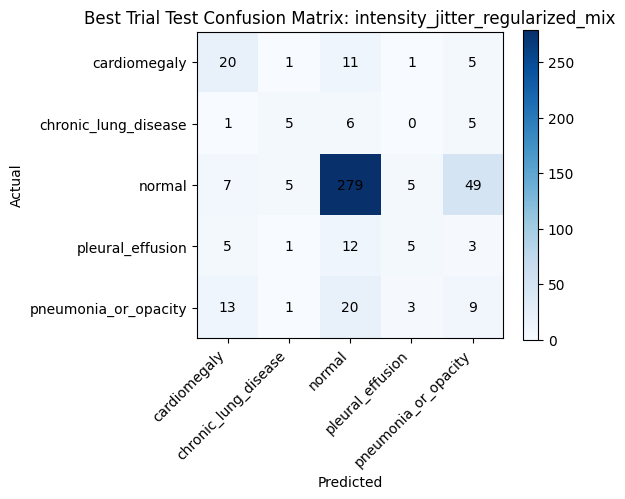

{
  "best_trial_name": "intensity_jitter_regularized_mix",
  "model_architecture": "Bio_ClinicalBERT residual gated fusion",
  "text_encoder": "emilyalsentzer/Bio_ClinicalBERT",
  "fusion_block": "ResidualGatedFusionBlock",
  "image_pipeline": "a_original_full",
  "image_pipeline_source": "notebook_04_original_full",
  "best_val_macro_f1": 0.5327797329965933,
  "test_accuracy": 0.673728813559322,
  "test_macro_f1": 0.40849865835006993,
  "test_weighted_f1": 0.6851406273941973,
  "checkpoint_path": "PROJECT_ROOT\\Experiments\\outputs\\experiment_05_gated_hypertuning_augmentation\\intensity_jitter_regularized_mix\\best_checkpoint.pt"
}


In [32]:
test_metrics = evaluate(model, test_loader, criterion, desc="Best Test")

best_output_dir = OUTPUT_DIR / "best_model_test"
best_output_dir.mkdir(parents=True, exist_ok=True)
save_json(config, best_output_dir / "best_trial_config.json")
save_json(test_metrics["report"], best_output_dir / "test_classification_report.json")
pd.DataFrame(
    test_metrics["confusion_matrix"],
    index=label_names,
    columns=label_names,
).to_csv(best_output_dir / "test_confusion_matrix.csv")
save_confusion_matrix_figure(
    test_metrics["confusion_matrix"],
    f"Best Trial Test Confusion Matrix: {best_trial_name}",
    best_output_dir / "test_confusion_matrix.png",
)

best_test_summary = {
    "best_trial_name": best_trial_name,
    "model_architecture": MODEL_ARCHITECTURE,
    "text_encoder": TEXT_ENCODER_NAME,
    "fusion_block": FUSION_BLOCK_NAME,
    "image_pipeline": IMAGE_PIPELINE_NAME,
    "image_pipeline_source": IMAGE_PIPELINE_SOURCE,
    "best_val_macro_f1": float(best_trial["best_val_macro_f1"]),
    "test_accuracy": test_metrics["accuracy"],
    "test_macro_f1": test_metrics["macro_f1"],
    "test_weighted_f1": test_metrics["weighted_f1"],
    "checkpoint_path": str(best_checkpoint),
}
save_json(best_test_summary, best_output_dir / "test_summary.json")
print(json.dumps(best_test_summary, indent=2))


---

# **Part 8: Results and Reporting**

### **Load Trial Leaderboard by Group**


In [33]:
summary_df = pd.read_csv(OUTPUT_DIR / "trial_summary.csv").sort_values(SELECTION_METRIC, ascending=False)
display(summary_df)

if "trial_group" in summary_df.columns:
    for group_name, group_df in summary_df.groupby("trial_group", sort=True):
        print(group_name)
        display(group_df.sort_values(SELECTION_METRIC, ascending=False))


,epochs,batch_size,lr_text,lr_image,weight_decay,text_dropout,classifier_dropout,class_weight_power,scheduler,freeze_bert,...,image_pipeline_source,checkpoint_policy,best_epoch,best_val_macro_f1,best_val_accuracy,elapsed_minutes,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,resume_start_epoch
0,10,32,0.00002,0.00010,0.0005,0.3,0.4,0.5,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,6,0.532780,0.781780,76.466012,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
1,10,32,0.00002,0.00010,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,7,0.503366,0.790254,28.311117,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,True,7
2,10,32,0.00002,0.00010,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,10,0.498416,0.758475,70.173300,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
3,10,32,0.00002,0.00010,0.0001,0.1,0.2,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,9,0.498346,0.779661,68.972250,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
4,10,32,0.00002,0.00010,0.0005,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,6,0.495055,0.786017,76.296855,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
5,10,32,0.00002,0.00010,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,10,0.494421,0.775424,70.839988,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
6,10,32,0.00002,0.00010,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,10,0.491531,0.773305,71.077862,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
7,10,32,0.00002,0.00010,0.0001,0.2,0.5,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,5,0.486890,0.769068,73.072826,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
8,10,32,0.00002,0.00010,0.0001,0.2,0.3,0.5,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,4,0.478569,0.775424,75.326694,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
9,10,32,0.00002,0.00010,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,4,0.474139,0.775424,6.074434,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,True,10


01_baseline_simple_aug


,epochs,batch_size,lr_text,lr_image,weight_decay,text_dropout,classifier_dropout,class_weight_power,scheduler,freeze_bert,...,image_pipeline_source,checkpoint_policy,best_epoch,best_val_macro_f1,best_val_accuracy,elapsed_minutes,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,resume_start_epoch
1,10,32,0.00002,0.0001,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,7,0.503366,0.790254,28.311117,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,True,7
5,10,32,0.00002,0.0001,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,10,0.494421,0.775424,70.839988,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
9,10,32,0.00002,0.0001,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,4,0.474139,0.775424,6.074434,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,True,10


02_combined_aug


,epochs,batch_size,lr_text,lr_image,weight_decay,text_dropout,classifier_dropout,class_weight_power,scheduler,freeze_bert,...,image_pipeline_source,checkpoint_policy,best_epoch,best_val_macro_f1,best_val_accuracy,elapsed_minutes,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,resume_start_epoch
2,10,32,0.00002,0.0001,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,10,0.498416,0.758475,70.173300,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
6,10,32,0.00002,0.0001,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,10,0.491531,0.773305,71.077862,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1


...

,epochs,batch_size,lr_text,lr_image,weight_decay,text_dropout,classifier_dropout,class_weight_power,scheduler,freeze_bert,...,image_pipeline_source,checkpoint_policy,best_epoch,best_val_macro_f1,best_val_accuracy,elapsed_minutes,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,resume_start_epoch
3,10,32,0.00002,0.0001,0.0001,0.1,0.2,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,9,0.498346,0.779661,68.972250,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
7,10,32,0.00002,0.0001,0.0001,0.2,0.5,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,5,0.486890,0.769068,73.072826,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
11,10,32,0.00002,0.0001,0.0001,0.3,0.4,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,8,0.444508,0.773305,69.363955,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1


04_learning_rate_tuning


,epochs,batch_size,lr_text,lr_image,weight_decay,text_dropout,classifier_dropout,class_weight_power,scheduler,freeze_bert,...,image_pipeline_source,checkpoint_policy,best_epoch,best_val_macro_f1,best_val_accuracy,elapsed_minutes,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,resume_start_epoch
10,10,32,0.00002,0.00020,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,4,0.456510,0.754237,75.901607,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
12,10,32,0.00002,0.00005,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,6,0.429320,0.775424,76.548530,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
13,10,32,0.00001,0.00010,0.0001,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,6,0.420782,0.762712,76.232845,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1


05_regularization_class_balance


,epochs,batch_size,lr_text,lr_image,weight_decay,text_dropout,classifier_dropout,class_weight_power,scheduler,freeze_bert,...,image_pipeline_source,checkpoint_policy,best_epoch,best_val_macro_f1,best_val_accuracy,elapsed_minutes,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,resume_start_epoch
0,10,32,0.00002,0.0001,0.0005,0.3,0.4,0.5,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,6,0.532780,0.781780,76.466012,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
4,10,32,0.00002,0.0001,0.0005,0.2,0.3,1.0,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,6,0.495055,0.786017,76.296855,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1
8,10,32,0.00002,0.0001,0.0001,0.2,0.3,0.5,constant,True,...,notebook_04_original_full,last checkpoint saved every epoch; best checkp...,4,0.478569,0.775424,75.326694,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,False,1


### **Compare Against Notebook 04 Baseline**


In [34]:
baseline_path = (
    base_dir
    / "Experiments"
    / "outputs"
    / "experiment_04_segmentation"
    / "a_original_full"
    / "run_summary.json"
)

notebook04_baseline = json.loads(
    baseline_path.read_text(encoding="utf-8")
)

baseline_row = {
    "source": "notebook_04_original_full",
    "model_architecture": notebook04_baseline.get(
        "model_architecture",
        MODEL_ARCHITECTURE,
    ),
    "text_encoder": notebook04_baseline.get(
        "text_encoder",
        TEXT_ENCODER_NAME,
    ),
    "fusion_block": notebook04_baseline.get(
        "fusion_block",
        FUSION_BLOCK_NAME,
    ),
    "image_pipeline": notebook04_baseline.get(
        "image_pipeline",
        IMAGE_PIPELINE_NAME,
    ),
    "val_accuracy": notebook04_baseline.get("val_accuracy"),
    "val_macro_f1": notebook04_baseline.get("val_macro_f1"),
    "test_accuracy": notebook04_baseline.get("test_accuracy"),
    "test_macro_f1": notebook04_baseline.get("test_macro_f1"),
}

display(pd.DataFrame([baseline_row]))

,source,model_architecture,text_encoder,fusion_block,image_pipeline,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1
0,notebook_04_original_full,Bio_ClinicalBERT residual gated fusion,emilyalsentzer/Bio_ClinicalBERT,ResidualGatedFusionBlock,a_original_full,0.779661,0.486512,0.737288,0.420343


### **Notebook 04 Baseline Comparison Interpretation**

The comparison against Notebook 04 is the most important checkpoint decision in this experiment. The tuned Notebook 05 model improves validation macro F1 from 0.487 to 0.533, but it does not improve the final held-out test result. Notebook 04 still performs better on the test set, with 0.737 accuracy and 0.420 macro F1 compared with Notebook 05 at 0.674 accuracy and 0.408 macro F1. This means the tuning sweep found a better validation candidate, but not a better final model.

### **Review Best Test Summary and Per-Class Metrics**


In [35]:
best_test_dir = OUTPUT_DIR / "best_model_test"

best_test_summary = json.loads(
    (best_test_dir / "test_summary.json").read_text(encoding="utf-8")
)
display(pd.DataFrame([best_test_summary]))

best_report = json.loads(
    (best_test_dir / "test_classification_report.json").read_text(encoding="utf-8")
)

per_class_df = pd.DataFrame(
    [
        {
            "class_name": class_name,
            **best_report[class_name],
        }
        for class_name in label_names
    ]
)[
    ["class_name", "precision", "recall", "f1-score", "support"]
]

display(per_class_df)

,best_trial_name,model_architecture,text_encoder,fusion_block,image_pipeline,image_pipeline_source,best_val_macro_f1,test_accuracy,test_macro_f1,test_weighted_f1,checkpoint_path
0,intensity_jitter_regularized_mix,Bio_ClinicalBERT residual gated fusion,emilyalsentzer/Bio_ClinicalBERT,ResidualGatedFusionBlock,a_original_full,notebook_04_original_full,0.53278,0.673729,0.408499,0.685141,PROJECT_ROOT\Exp...


,class_name,precision,recall,f1-score,support
0,cardiomegaly,0.434783,0.526316,0.476190,38.0
1,chronic_lung_disease,0.384615,0.294118,0.333333,17.0
2,normal,0.850610,0.808696,0.829123,345.0
3,pleural_effusion,0.357143,0.192308,0.250000,26.0
4,pneumonia_or_opacity,0.126761,0.195652,0.153846,46.0


### **Best Test Result Interpretation**

The best tuned checkpoint still reflects the central difficulty of the project: the model is strongest on the majority normal class and less reliable on smaller abnormal classes. On the held-out test set, the tuned model reached 0.674 accuracy, 0.408 macro F1, and 0.685 weighted F1. Normal cases reached the highest class F1 at 0.829, while pneumonia or opacity remained much weaker at 0.154. This result shows why accuracy alone is not enough for this project and why the Notebook 04 checkpoint should remain the final model unless a later run improves minority-class performance on the test set.

---

# **Part 9: Conclusion**

This notebook tested whether hyperparameter tuning and augmentation could improve the selected Bio_ClinicalBERT residual gated fusion model carried forward from Notebook 04. The strongest validation result came from intensity_jitter_regularized_mix, which reached 0.5328 validation macro F1 compared with 0.4865 for the Notebook 04 full-image baseline. This shows that moderate intensity augmentation, regularization, and softer class weighting can make the validation behavior more balanced across classes.

That validation improvement did not carry over to the held-out test set. The tuned Notebook 05 checkpoint reached 0.6737 test accuracy, 0.4085 test macro F1, and 0.6851 test weighted F1, while the Notebook 04 full-image checkpoint remained stronger with 0.7373 test accuracy and 0.4203 test macro F1. This means the tuned model therefore looks useful as an experiment, but not strong enough to replace the prior checkpoint.

The per-class results also support a nuanced interpretation The tuned model still performs best on the majority normal class and remains less stable on smaller abnormal categories such as pleural effusion and pneumonia or opacity. Because this project is focused on clinically important classification instead of only accuracy, the final model choice should prioritize held-out test macro F1 and minority-class behavior.

The final recommendation is to retain the Notebook 04 original full-image Bio_ClinicalBERT residual gated fusion checkpoint as the final model for this project. Notebook 05 is still useful because it shows that regularization and class balancing can raise validation macro F1, but the tuned checkpoint should not replace the final model unless a future run also improves held-out test performance. Notebook 06 will therefore explain the retained Notebook 04 checkpoint with Grad-CAM.
